In [1]:
from tensorflow.keras.models import load_model

model = load_model("../models/resnet50_final.keras")
print("Model loaded")

Model loaded


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

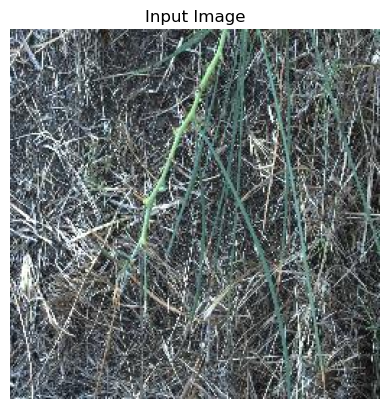

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input

img_path = r"C:\Users\Soumyajit\OneDrive\Desktop\WeedDetection\data\processed\Parkinsonia\20170920-093829-1.jpg"  

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Input Image")
plt.axis("off")

In [13]:
img_resized = cv2.resize(img_rgb, (160,160))
img_array = np.expand_dims(img_resized, axis=0)
img_array = preprocess_input(img_array)

In [14]:
import os
import numpy as np

# get class names from train folder
class_names = sorted(os.listdir("../data/train"))
print("Classes:", class_names)

Classes: ['Chinee apple', 'Lantana', 'Negative', 'Parkinsonia', 'Parthenium', 'Prickly acacia', 'Rubber vine', 'Siam weed', 'Snake weed', 'Unknown']


In [15]:
pred = model.predict(img_array)

label = class_names[np.argmax(pred)]

print("Detected weed:", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Detected weed: Parkinsonia


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

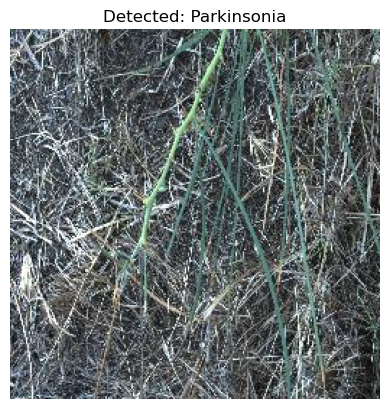

In [16]:
plt.imshow(img_rgb)
plt.title(f"Detected: {label}")
plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


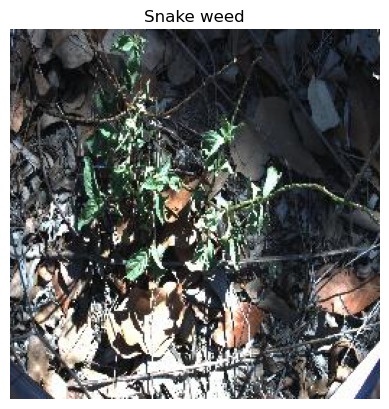

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


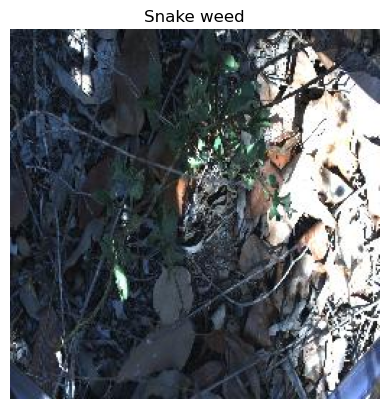

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


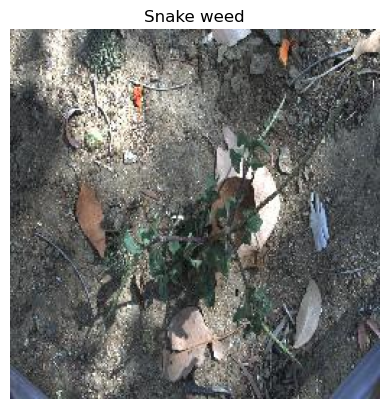

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


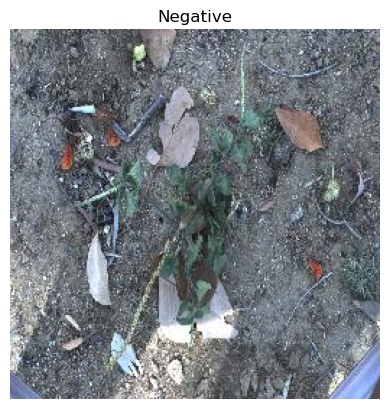

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


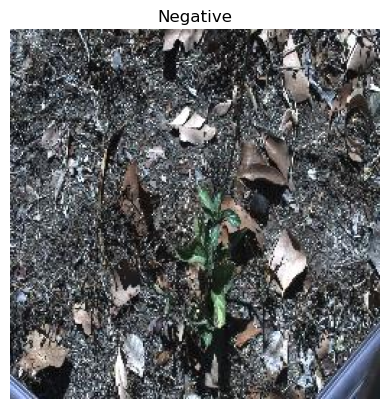

In [20]:
import glob

folder = r"C:\Users\Soumyajit\OneDrive\Desktop\WeedDetection\data\processed\Snake weed\*.jpg"  # change to your folder path

for path in glob.glob(folder)[:5]:
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (160,160))
    arr = np.expand_dims(img_resized,0)
    arr = preprocess_input(arr)

    pred = model.predict(arr)
    label = class_names[np.argmax(pred)]

    plt.imshow(img_rgb)
    plt.title(label)
    plt.axis("off")
    plt.show()